# Analyse des données XAgriScan
Ce notebook permet d'analyser et de visualiser les images présentes dans le dossier `../data`.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

data_dir = '../data'
phases = ['train', 'val', 'test']

# Récupérer les classes à partir du dossier train
train_path = os.path.join(data_dir, 'train')
if os.path.exists(train_path):
    classes = os.listdir(train_path)
    print('Classes trouvées :', classes)
else:
    print(f"Le chemin {train_path} n'existe pas.")
    classes = []

Classes trouvées : ['apple_frogeye_leaf_spot', 'apple_leaf_healthy', 'apple_mosaic_leaf', 'apple_powdery_mildew_leaf', 'apple_rust_leaf', 'apple_scab_leaf']


In [3]:
# Compter le nombre d'images par classe et par phase
counts = []
for phase in phases:
    for cls in classes:
        path = os.path.join(data_dir, phase, cls)
        if os.path.isdir(path):
            num_images = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            counts.append({'Phase': phase, 'Classe': cls, 'Nombre d\'images': num_images})

df_counts = pd.DataFrame(counts)
# Affichage sous forme de tableau croisé pour bien voir train, val et test
df_pivot = df_counts.pivot(index='Classe', columns='Phase', values='Nombre d\'images')
display(df_pivot)

Phase,test,train,val
Classe,,,
apple_frogeye_leaf_spot,38,176,38
apple_leaf_healthy,39,170,40
apple_mosaic_leaf,38,175,37
apple_powdery_mildew_leaf,38,175,38
apple_rust_leaf,39,172,41
apple_scab_leaf,38,170,37


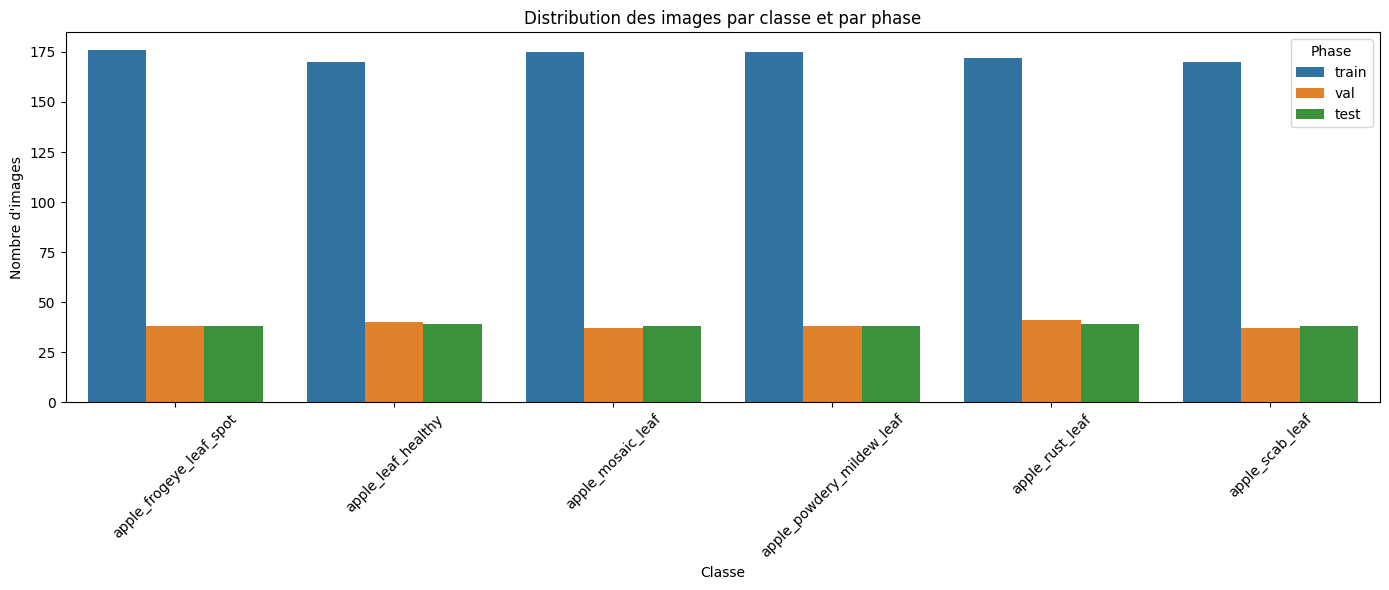

In [4]:
# Visualisation de la distribution
if not df_counts.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_counts, x='Classe', y='Nombre d\'images', hue='Phase')
    plt.title('Distribution des images par classe et par phase')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

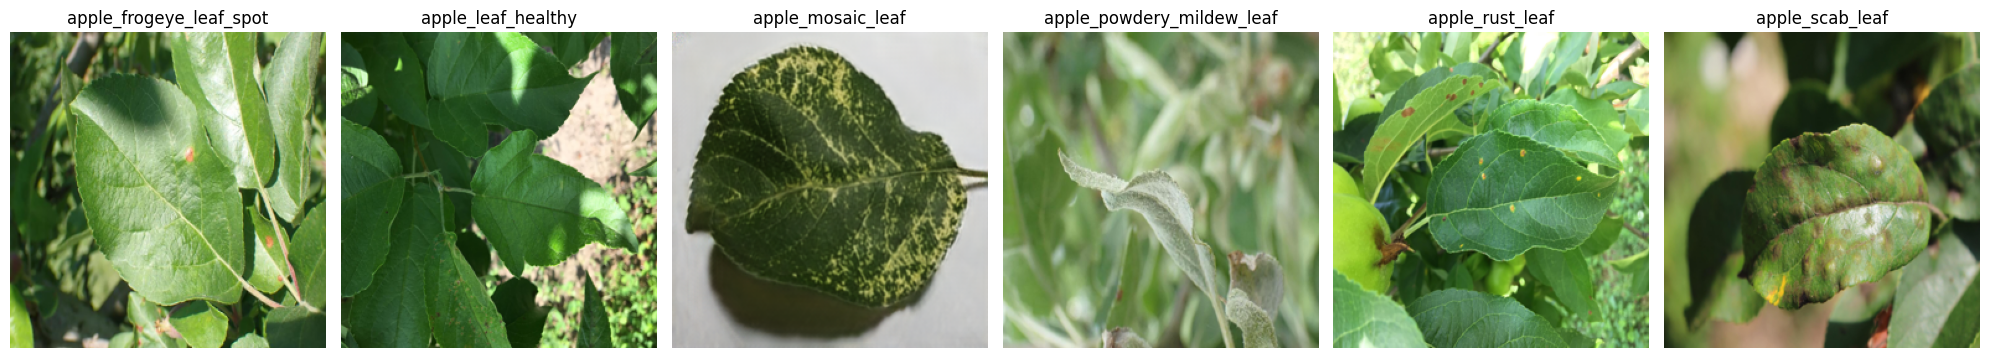

In [8]:
# Affichage de quelques échantillons d'images
import random

if classes:
    fig, axes = plt.subplots(1, len(classes), figsize=(20, 8))
    for i, cls in enumerate(classes):
        path = os.path.join(data_dir, 'train', cls)
        if os.path.isdir(path):
            images = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if images:
                img_name = random.choice(images)
                img_path = os.path.join(path, img_name)
                img = Image.open(img_path)
                img= img.resize((255,255))
                axes[i].imshow(img)
                axes[i].set_title(cls)
                axes[i].axis('off')
    plt.tight_layout()
    plt.show()